# Titanic Dataset Preprocessing and Feature Engineering

## Objective

The objective of this notebook is to assess the quality of the Titanic dataset, perform data preprocessing, apply feature engineering techniques, prepare the data for machine learning, and build a reusable preprocessing pipeline using Scikit-Learn.

The notebook demonstrates concepts including:

- Data quality assessment
- Missing value treatment
- Categorical encoding
- Numerical preprocessing
- Feature engineering
- Data splitting
- Data leakage prevention
- Scikit-Learn Pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("titanic.csv")
df.head()

,Unnamed: 0,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,0,1,0,1,0.2750,0.014151,0,0,1,0.1,1,0,0,0,0,0,1
1,1,2,1,0,0.4750,0.139136,1,0,0,0.1,1,0,0,0,1,0,0
2,2,3,1,0,0.3250,0.015469,0,0,1,0.0,0,0,0,1,0,0,1
3,3,4,1,0,0.4375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1
4,4,5,0,1,0.4375,0.015713,0,0,1,0.0,1,0,0,0,0,0,1


In [4]:
print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)
df.info()

print("\n")

print("="*50)
print("Statistical Summary")
print("="*50)
df.describe(include="all")

Dataset Shape
(892, 17)


Data Types
Unnamed: 0       int64
PassengerId      int64
Survived         int64
Sex              int64
Age            float64
Fare           float64
Pclass_1         int64
Pclass_2         int64
Pclass_3         int64
Family_size    float64
Title_1          int64
Title_2          int64
Title_3          int64
Title_4          int64
Emb_1            int64
Emb_2            int64
Emb_3            int64
dtype: object


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   892 non-null    int64  
 1   PassengerId  892 non-null    int64  
 2   Survived     892 non-null    int64  
 3   Sex          892 non-null    int64  
 4   Age          892 non-null    float64
 5   Fare         892 non-null    float64
 6   Pclass_1     892 non-null    int64  
 7   Pclass_2     892 non-null    int64  
 8   Pclass

,Unnamed: 0,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
count,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000
mean,445.387892,446.387892,0.383408,0.647982,0.366833,0.062845,0.242152,0.207399,0.550448,0.090359,0.747758,0.005605,0.044843,0.201794,0.188341,0.086323,0.723094
std,257.470149,257.470149,0.486489,0.477867,0.162751,0.096942,0.428626,0.405671,0.497728,0.161284,0.434543,0.074701,0.207075,0.401564,0.391203,0.280998,0.447721
min,0.000000,1.000000,0.000000,0.000000,0.005250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,222.750000,223.750000,0.000000,0.000000,0.275000,0.015454,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,445.500000,446.500000,0.000000,1.000000,0.350000,0.028213,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,668.250000,669.250000,1.000000,1.000000,0.437500,0.060508,0.000000,0.000000,1.000000,0.100000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,890.000000,891.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Missing Values,Percentage
Unnamed: 0,0,0.0
Family_size,0,0.0
Emb_2,0,0.0
Emb_1,0,0.0
Title_4,0,0.0
Title_3,0,0.0
Title_2,0,0.0
Title_1,0,0.0
Pclass_3,0,0.0
PassengerId,0,0.0


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 1


In [7]:
print("Negative Ages:")
print(df[df["Age"] < 0])

print()

print("Negative Fare:")
print(df[df["Fare"] < 0])

Negative Ages:
Empty DataFrame
Columns: [Unnamed: 0, PassengerId, Survived, Sex, Age, Fare, Pclass_1, Pclass_2, Pclass_3, Family_size, Title_1, Title_2, Title_3, Title_4, Emb_1, Emb_2, Emb_3]
Index: []

Negative Fare:
Empty DataFrame
Columns: [Unnamed: 0, PassengerId, Survived, Sex, Age, Fare, Pclass_1, Pclass_2, Pclass_3, Family_size, Title_1, Title_2, Title_3, Title_4, Emb_1, Emb_2, Emb_3]
Index: []


In [8]:
categorical = df.select_dtypes(include="object").columns

for col in categorical:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [9]:
for col in categorical:
    print("="*40)
    print(col)
    print(df[col].value_counts())

ValueError: num must be an integer with 1 <= num <= 8, not 9

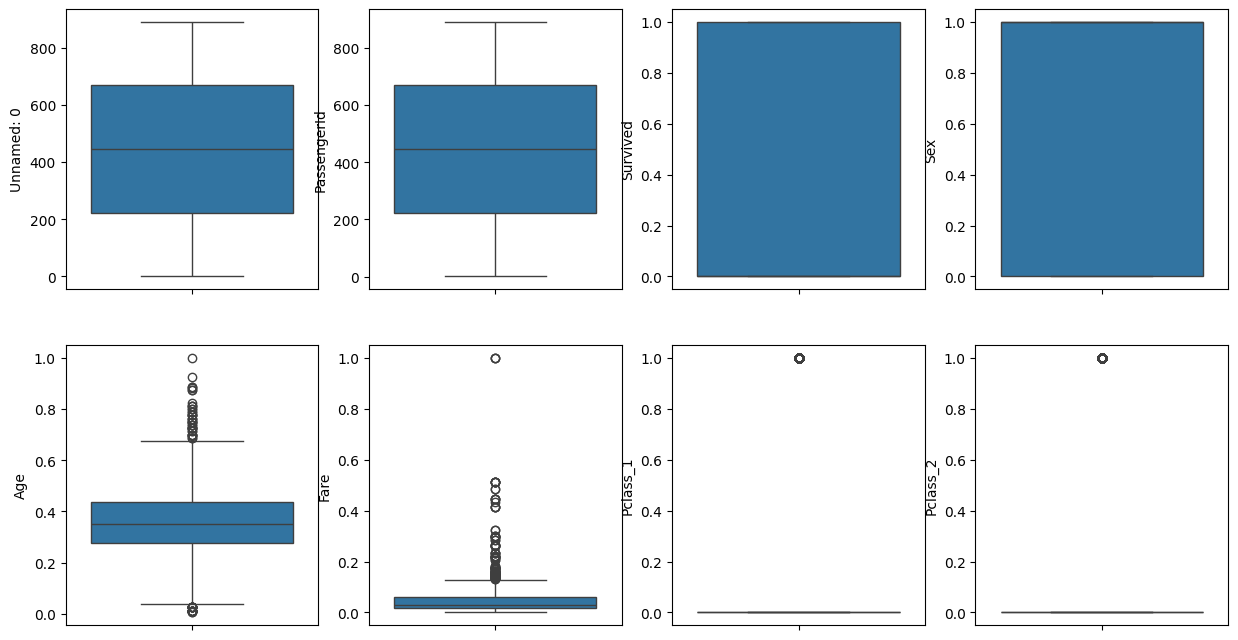

In [10]:
numerical = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))

for i,col in enumerate(numerical):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [11]:
for col in numerical:

    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    outliers = df[
        (df[col]<lower) |
        (df[col]>upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Unnamed: 0: 0 outliers
PassengerId: 0 outliers
Survived: 0 outliers
Sex: 0 outliers
Age: 66 outliers
Fare: 116 outliers
Pclass_1: 216 outliers
Pclass_2: 185 outliers
Pclass_3: 0 outliers
Family_size: 91 outliers
Title_1: 0 outliers
Title_2: 5 outliers
Title_3: 40 outliers
Title_4: 180 outliers
Emb_1: 168 outliers
Emb_2: 77 outliers
Emb_3: 0 outliers


In [12]:
print(df.isnull().sum())

Unnamed: 0     0
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


In [13]:
row_deleted = df.dropna()

print(row_deleted.shape)

(892, 17)


In [14]:
column_deleted = df.drop(columns=["Cabin"])

column_deleted.head()

KeyError: "['Cabin'] not found in axis"

In [15]:
mean_df = df.copy()

mean_df["Age"] = mean_df["Age"].fillna(
    mean_df["Age"].mean()
)

In [16]:
median_df = df.copy()

median_df["Age"] = median_df["Age"].fillna(
    median_df["Age"].median()
)

In [17]:
mode_df = df.copy()

mode_df["Embarked"] = mode_df["Embarked"].fillna(
    mode_df["Embarked"].mode()[0]
)

KeyError: 'Embarked'

In [18]:
knn_df = df.copy()

knn = KNNImputer(n_neighbors=5)

knn_df[["Age","Fare"]] = knn.fit_transform(
    knn_df[["Age","Fare"]]
)

In [19]:
titanic = df.copy()

# Remove Cabin because of excessive missing values
titanic.drop("Cabin", axis=1, inplace=True)

# Fill missing values
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

titanic.isnull().sum()

KeyError: "['Cabin'] not found in axis"

In [20]:
le = LabelEncoder()

titanic["Sex_Label"] = le.fit_transform(titanic["Sex"])

titanic[["Sex","Sex_Label"]].head()

,Sex,Sex_Label
0,1,1
1,0,0
2,0,0
3,0,0
4,1,1


In [21]:
ordinal = OrdinalEncoder()

titanic["Embarked_Ordinal"] = ordinal.fit_transform(
    titanic[["Embarked"]]
)

titanic[["Embarked","Embarked_Ordinal"]].head()

KeyError: "None of [Index(['Embarked'], dtype='object')] are in the [columns]"

In [22]:
ticket_freq = titanic["Ticket"].value_counts()

rare = ticket_freq[ticket_freq < 3].index

titanic["Ticket"] = titanic["Ticket"].replace(
    rare,
    "Rare"
)

KeyError: 'Ticket'

In [23]:
standard = StandardScaler()

titanic["Age_Standard"] = standard.fit_transform(
    titanic[["Age"]]
)

In [24]:
minmax = MinMaxScaler()

titanic["Fare_MinMax"] = minmax.fit_transform(
    titanic[["Fare"]]
)

In [25]:
robust = RobustScaler()

titanic["Fare_Robust"] = robust.fit_transform(
    titanic[["Fare"]]
)

In [26]:
titanic["Fare_Log"] = np.log1p(titanic["Fare"])

In [27]:
Q1 = titanic["Fare"].quantile(.25)
Q3 = titanic["Fare"].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

titanic["Fare"] = titanic["Fare"].clip(lower, upper)

In [28]:
titanic["FamilySize"] = (
    titanic["SibSp"] +
    titanic["Parch"] +
    1
)

KeyError: 'SibSp'

In [29]:
titanic["IsAlone"] = (
    titanic["FamilySize"] == 1
).astype(int)

KeyError: 'FamilySize'

In [30]:
titanic["Title"] = (
    titanic["Name"]
    .str.extract(" ([A-Za-z]+)\.")
)

KeyError: 'Name'

In [31]:
common = ["Mr","Mrs","Miss","Master"]

titanic["Title"] = titanic["Title"].apply(
    lambda x: x if x in common else "Other"
)

KeyError: 'Title'

In [32]:
titanic = pd.get_dummies(
    titanic,
    columns=["Title"],
    drop_first=True
)

KeyError: "None of [Index(['Title'], dtype='object')] are in the [columns]"

In [33]:
titanic["AgeGroup"] = pd.cut(
    titanic["Age"],
    bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

In [34]:
titanic["FarePerPerson"] = (
    titanic["Fare"] /
    titanic["FamilySize"]
)

KeyError: 'FamilySize'

In [35]:
titanic["ClassAge"] = (
    titanic["Pclass"] *
    titanic["Age"]
)

KeyError: 'Pclass'

In [36]:
X = titanic.drop(
    columns=[
        "Survived",
        "Name",
        "Ticket",
        "PassengerId"
    ]
)

y = titanic["Survived"]

KeyError: "['Name', 'Ticket'] not found in axis"

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'X' is not defined

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=.25,
    random_state=42
)

NameError: name 'X_train' is not defined

In [39]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y,
    test_size=.2,
    stratify=y,
    random_state=42
)

NameError: name 'X' is not defined

## Data Leakage

Target leakage occurs when information from the target variable is accidentally included in the predictor variables.

Training-test contamination happens when preprocessing techniques such as scaling or imputation are performed before splitting the dataset.

To prevent leakage:

- Split the data before preprocessing.
- Fit imputers only on the training set.
- Fit scalers only on the training set.
- Apply the trained transformations to the validation and test sets.

In [40]:
num_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

cat_features = [
    "Sex",
    "Embarked"
    "Title"
]

In [41]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [42]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'SibSp', 'Parch']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'EmbarkedTitle'])])

In [43]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

NameError: name 'X_train' is not defined

In [44]:
titanic.to_csv(
    "titanic_feature_engineered.csv",
    index=False
)

# Conclusion

The Titanic dataset was successfully cleaned and prepared for machine learning. Missing values were treated using multiple techniques, categorical variables were encoded, numerical variables were scaled, outliers were handled, and several new features were engineered. A reusable Scikit-Learn preprocessing pipeline was created to ensure reproducibility and to prevent data leakage. The processed dataset is now suitable for building predictive machine learning models.